In [50]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250716-r1-explore-exploit-tension',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'SHOC2_HUMAN_Kwon_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'BLAT_ECOLX_Firnberg_2014', 'OXDA_RHOTO_Vanella_2023_activity', 'PPM1D_HUMAN_Miller_2022', 'ANCSZ_Hobbs_2022', 'CBS_HUMAN_Sun_2020', 'HSP82_YEAST_Flynn_2019', 'HEM3_HUMAN_Loggerenberg_2023'}


<Axes: xlabel='round_num', ylabel='held_out_10pct_recall'>

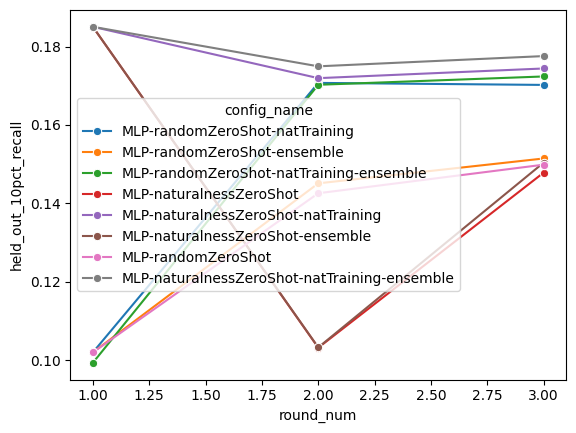

In [51]:
sns.lineplot(
    data=round_metrics_df,
    # y='held_out_activity_spearman',
    y='held_out_10pct_recall',
    # y='held_out_1pct_auc',
    # y='held_out_activity_spearman',
    x='round_num',
    hue='config_name',
    errorbar=None,
    marker='o',
    # style='config_name',
    # errorbar=None
)

Text(0.5, 0, '')

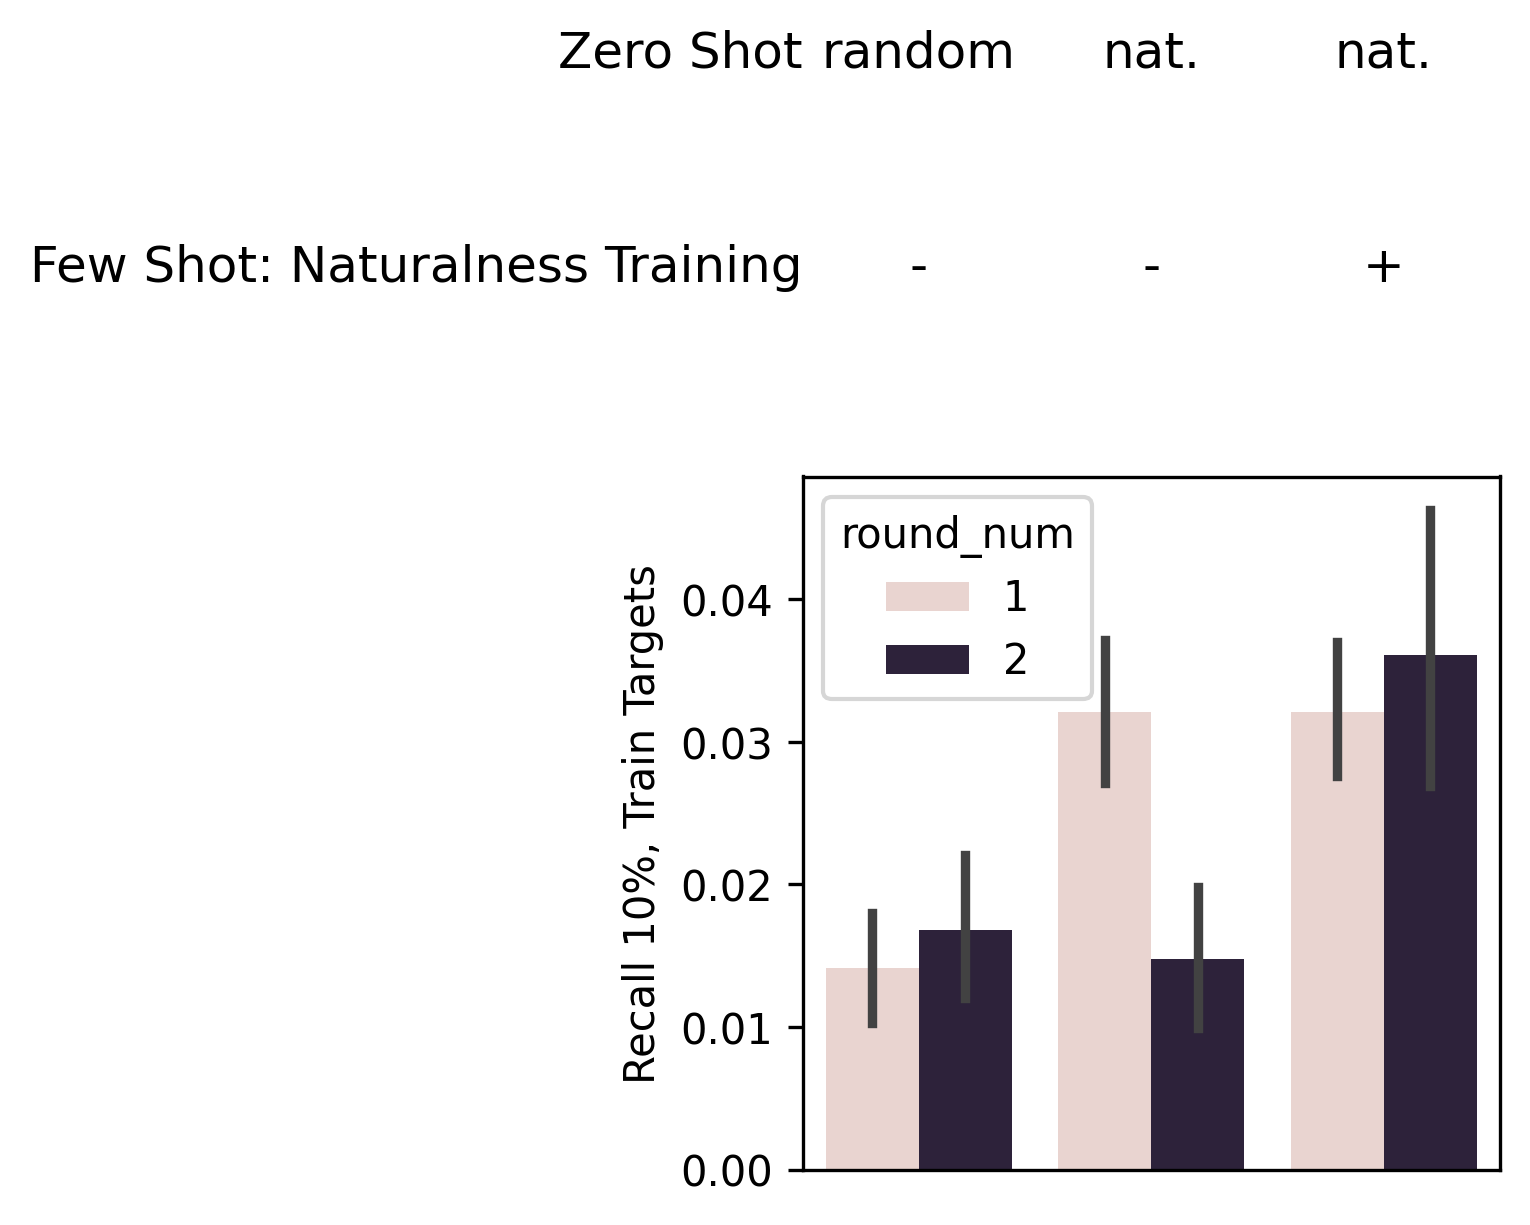

In [58]:
METRIC = 'held_out_1pct_recall'

configs = [
    ('MLP-randomZeroShot', 'Random First Round'),
    ('MLP-naturalnessZeroShot', 'Naturalness First Round'),
    ('MLP-naturalnessZeroShot-natTraining', 'Naturalness First Round +\nTraining'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]

plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

plt.figure(figsize=(3, 3), dpi=300)
ax = sns.barplot(
    data=plot_df[(plot_df.round_num <= 2) & (plot_df.config_name.isin([c for _, c in configs]))],
    x='config_name',
    y=METRIC,
    hue='round_num',
    order=[c for _, c in configs],
)

treatment_matrix = [
    ['random', 'nat.', 'nat.'],
    ['-', '-', '+'],
]

row_labels = ['Zero Shot', 'Few Shot: Naturalness Training']
for i, label in enumerate(row_labels):
    y = 0.08 - i * 0.015  # control vertical spacing
    for j, sym in enumerate(treatment_matrix[i]):
        ax.text(j, y, sym, ha='center', va='top', fontsize=12)
    # Optional: add row label on the left
    ax.text(-0.5, y, label, ha='right', va='top', fontsize=12)

# Clean up plot
# ax.set_ylim(0.09, 0.22)
ax.set_ylabel('Recall 10%, Train Targets')
# ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.set_xticks([])  # hide original x-axis labels if desired
# ax.axhline(y=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')


plt.xlabel('')